# Study 846 — Blockbuster Game-Launch Drift 🕹️

*For the curious.* When a marquee AAA game ships — **GTA V**, **Red Dead Redemption 2**, **Zelda: Tears of the Kingdom**, **Battlefield**, **Assassin's Creed** — does the **publisher's stock** move? Folklore says *buy the hype into launch day* and then either ride the momentum or *sell the news*. We put **~33 blockbuster launches (2013→2024)** on the stand — mapped to **TTWO** (Rockstar/2K), **EA**, **NTDOY** (Nintendo) and **UBSFY** (Ubisoft) — and asked two plain questions: **does the publisher rally into the launch?** and **does it drift after it?** The answer is a quiet double bust.

## The claim

A blockbuster launch is a scheduled, heavily-marketed, months-in-advance ship — the retail 'buy the hype' reflex says load up on the publisher into launch day and ride the drift. The catch that kills it before we start: the date is *known* far ahead, and one title is a small slice of a giant multi-franchise publisher (TTWO also ships NBA 2K; EA also ships FC and Apex; Nintendo ships a whole platform). We measure the publisher's **abnormal** return (publisher − SPY, total-return) so we're not just measuring the market — each launch anchored to *its own* publisher. Note: **ATVI** (Call of Duty, Diablo IV) is in the calendar for the record but has **no tape** — Microsoft's buyout delisted it on 2023-10-13 — so its five launches are honestly excluded, not silently dropped.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from game_launch import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching TTWO + EA + NTDOY + UBSFY + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} launches resolved "
      f"(4 ATVI launches carry no tape — Activision delisted 2023-10-13)")


panel loaded; 33 of 37 launches resolved (4 ATVI launches carry no tape — Activision delisted 2023-10-13)


## The launch calendar we test (hardcoded from Wikipedia / press releases)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['launch', 'publisher', 'title'])

,launch,publisher,title
0,2013-09-17,TTWO,Grand Theft Auto V
1,2014-11-18,TTWO,Grand Theft Auto V (next-gen)
2,2015-04-14,TTWO,Grand Theft Auto V (PC)
3,2016-10-07,TTWO,Mafia III
4,2016-10-21,TTWO,Civilization VI
5,2018-10-26,TTWO,Red Dead Redemption 2
6,2019-09-13,TTWO,Borderlands 3
7,2016-10-21,EA,Battlefield 1
8,2017-03-21,EA,Mass Effect: Andromeda
9,2017-11-17,EA,Star Wars Battlefront II


## The picture: mean cumulative abnormal return around the launch

Offset 0 is the launch. Left of zero is the *run-up* (the supposed hype rally); right of zero is the *drift* window out to ~1 month (ride it or sell the news).

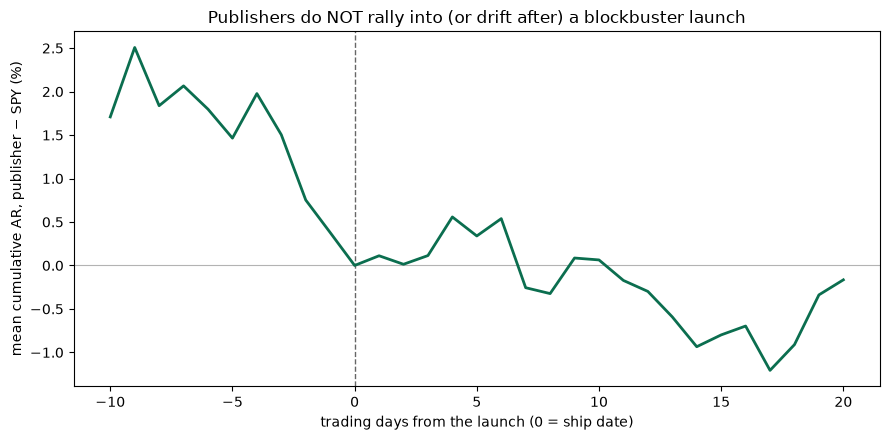

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#0b6e4f', lw=2)
ax.set_xlabel('trading days from the launch (0 = ship date)')
ax.set_ylabel('mean cumulative AR, publisher − SPY (%)')
ax.set_title('Publishers do NOT rally into (or drift after) a blockbuster launch')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 1-week run-up | -1.38% | -1.32 | 8/33 |
| 2-week run-up | -1.58% | -1.26 | 13/33 |
| 1-week drift | +0.34% | +0.38 | 18/33 |
| ~1-month drift (20d) | -0.17% | -0.10 | 16/33 |

The bullish folklore just **isn't there**. If anything the publisher *drifts down* into the launch (-1.58% over two weeks) — the **wrong way** for 'buy the hype' — but it's **not significant** (*t* = -1.26, |*t*| < 2). And the headline **20-day post-launch drift is a clean zero** (-0.17%, *t* = -0.10, hit 16/33 — an essentially even coin flip). No hype premium, no momentum, no sell-the-news edge.

In [4]:
rows = [('1wk run-up','pre_s'),('2wk run-up','pre_l'),('1wk drift','post_s'),('20d drift','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<11s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

1wk run-up  n=33  mean=-1.381%  t=-1.316  hit 8/33
2wk run-up  n=33  mean=-1.581%  t=-1.259  hit 13/33
1wk drift   n=33  mean=+0.339%  t=+0.383  hit 18/33
20d drift   n=33  mean=-0.165%  t=-0.098  hit 16/33


## So what?

The finance version of 'buy the hype into a game launch' is folklore: publishers don't rally into a launch (a faint, insignificant *dip* if anything — the wrong way) and don't drift after it (a clean 20-day zero). On top of the missing signal, the date is public months ahead and a single title is a small slice of a huge publisher's revenue. Verdict: **None signal, Mirage tradability.** The quants' notebook has the placebo, the per-publisher and sub-era splits, the jackknife, the costed leg and the synthetic control.